# 02. Environment Validation

This notebook validates the Week 2 modules and their integration with Week 1:
1. **Noise models** - `NoiseConfig` and `build_noisy_circuit` produce correct circuits
2. **Gymnasium environment** - `SurfaceCodeEnv` observation/action spaces, episode flow
3. **Reward variants** - Sparse, potential-based, and heuristic shaping
4. **Oracle verification** - Commit-only agent at zero noise is perfect; MWPM outperforms it at nonzero noise
5. **Integration** - End-to-end: noise model → circuit → env → episode → reward

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.quantum.surface_code import SurfaceCodeParams, generate_circuit
from src.quantum.syndrome import SyndromeGrid, visualize_syndrome
from src.quantum.decoder_baseline import MWPMDecoder
from src.quantum.noise_models import NoiseConfig, NoiseModelType, build_noisy_circuit
from src.envs.surface_code_env import SurfaceCodeEnv
from src.envs.reward import RewardType

%matplotlib inline
plt.rcParams.update({'font.size': 12, 'figure.figsize': (8, 6), 'savefig.dpi': 150})

## 1. Noise Models

Verify that `NoiseConfig` + `build_noisy_circuit` produce circuits consistent with the raw `generate_circuit` API from week 1.

In [ ]:
# create depolarizing noise configs at several error rates
configs = {}
for p in [0.0, 0.001, 0.01, 0.05]:
    configs[p] = NoiseConfig(NoiseModelType.DEPOLARIZING, p)
    print(f"p={p}: {configs[p]}")

p=0.0: NoiseConfig(model_type=<NoiseModelType.DEPOLARIZING: 'depolarizing'>, physical_error_rate=0.0, bias_ratio=1.0, correlation_strength=0.0)
p=0.001: NoiseConfig(model_type=<NoiseModelType.DEPOLARIZING: 'depolarizing'>, physical_error_rate=0.001, bias_ratio=1.0, correlation_strength=0.0)
p=0.01: NoiseConfig(model_type=<NoiseModelType.DEPOLARIZING: 'depolarizing'>, physical_error_rate=0.01, bias_ratio=1.0, correlation_strength=0.0)
p=0.05: NoiseConfig(model_type=<NoiseModelType.DEPOLARIZING: 'depolarizing'>, physical_error_rate=0.05, bias_ratio=1.0, correlation_strength=0.0)


In [ ]:
# build circuits and compare syndrome rates
params = SurfaceCodeParams(distance=3, rounds=3)

print("Noise model API vs raw Stim API comparison:")
print("=" * 60)

for p, config in configs.items():
    sc = build_noisy_circuit(params, config)
    syn, obs = sc.sample(5000, seed=42)
    print(f"p={p:.3f}: mean_syndrome_weight={syn.sum(axis=1).mean():.2f}, "
          f"obs_flip_rate={obs.mean():.4f}")

print("\nCross-check with raw generate_circuit at p=0.01:")
raw_noise = {
    "after_clifford_depolarization": 0.01,
    "before_round_data_depolarization": 0.01,
    "before_measure_flip_probability": 0.01,
    "after_reset_flip_probability": 0.01,
}
sc_raw = generate_circuit(params, raw_noise)
syn_raw, obs_raw = sc_raw.sample(5000, seed=42)
print(f"Raw API: mean_syndrome_weight={syn_raw.sum(axis=1).mean():.2f}, "
      f"obs_flip_rate={obs_raw.mean():.4f}")

Noise model API vs raw Stim API comparison:
p=0.000: mean_syndrome_weight=0.00, obs_flip_rate=0.0000
p=0.001: mean_syndrome_weight=0.30, obs_flip_rate=0.0194
p=0.010: mean_syndrome_weight=2.62, obs_flip_rate=0.1884
p=0.050: mean_syndrome_weight=8.43, obs_flip_rate=0.4474

Cross-check with raw generate_circuit at p=0.01:
Raw API: mean_syndrome_weight=2.62, obs_flip_rate=0.1884


In [ ]:
# compare depolarizing vs measurement-dominated noise
p = 0.05
depol = NoiseConfig(NoiseModelType.DEPOLARIZING, p)
meas = NoiseConfig(NoiseModelType.MEASUREMENT, p)

params5 = SurfaceCodeParams(distance=5, rounds=5)

sc_depol = build_noisy_circuit(params5, depol)
sc_meas = build_noisy_circuit(params5, meas)

syn_d, obs_d = sc_depol.sample(5000, seed=42)
syn_m, obs_m = sc_meas.sample(5000, seed=42)

print(f"Depolarizing (p={p}):")
print(f"  Mean syndrome weight: {syn_d.sum(axis=1).mean():.2f}")
print(f"  Observable flip rate: {obs_d.mean():.4f}")

print(f"\nMeasurement-dominated (p={p}):")
print(f"  Mean syndrome weight: {syn_m.sum(axis=1).mean():.2f}")
print(f"  Observable flip rate: {obs_m.mean():.4f}")
print(f"\nMeasurement-dominated has lower gate noise (p/10),")
print(f"so fewer real errors but similar measurement noise.")

Depolarizing (p=0.05):
  Mean syndrome weight: 45.86
  Observable flip rate: 0.4940

Measurement-dominated (p=0.05):
  Mean syndrome weight: 17.65
  Observable flip rate: 0.3376

Measurement-dominated has lower gate noise (p/10),
so fewer real errors but similar measurement noise.


## 2. Environment Spaces & Episode Flow

Verify observation/action space dimensions and run a manual episode.

In [ ]:
# create environments for d=3 and d=5
for d in [3, 5]:
    env = SurfaceCodeEnv.from_config(distance=d, physical_error_rate=0.01)
    print(f"\nd={d}:")
    print(f"  Observation space: {env.observation_space.shape}")
    print(f"  Action space: {env.action_space.n} actions")
    print(f"  Data qubits: {d**2}")
    print(f"  Actions breakdown:")
    print(f"    X corrections: 0..{d**2-1}")
    print(f"    Z corrections: {d**2}..{2*d**2-1}")
    print(f"    Y corrections: {2*d**2}..{3*d**2-1}")
    print(f"    Commit: {3*d**2}")


d=3:
  Observation space: (6, 4, 4)
  Action space: 28 actions
  Data qubits: 9
  Actions breakdown:
    X corrections: 0..8
    Z corrections: 9..17
    Y corrections: 18..26
    Commit: 27

d=5:
  Observation space: (8, 6, 6)
  Action space: 76 actions
  Data qubits: 25
  Actions breakdown:
    X corrections: 0..24
    Z corrections: 25..49
    Y corrections: 50..74
    Commit: 75


In [ ]:
# run manual episode: observe syndrome, apply some corrections, commit
env = SurfaceCodeEnv.from_config(distance=3, physical_error_rate=0.02)
obs, info = env.reset()

print("=== Manual Episode (d=3) ===")
print(f"Initial syndrome weight: {info['syndrome_weight']}")
print(f"Observation shape: {obs.shape}")
print(f"Syndrome channels (first 4): nonzero entries = {(obs[:4] > 0).sum()}")
print(f"X correction channel: all zeros = {(obs[4] == 0).all()}")
print(f"Z correction channel: all zeros = {(obs[5] == 0).all()}")

# apply X correction on qubit 0
obs, reward, term, trunc, info = env.step(0)
print(f"\nAfter X on qubit 0: reward={reward}, terminated={term}")
print(f"X correction channel nonzero: {(obs[4] > 0).sum()}")

# apply X correction on qubit 0 again (should cancel)
obs, reward, term, trunc, info = env.step(0)
print(f"After X on qubit 0 again (cancel): X channel nonzero: {(obs[4] > 0).sum()}")

# commit all rounds
for r in range(3):
    obs, reward, term, trunc, info = env.step(env._commit_action)
    print(f"Commit round {r}: reward={reward:.2f}, terminated={term}")

print(f"\nEpisode result: success={info.get('success')}")

=== Manual Episode (d=3) ===
Initial syndrome weight: 1
Observation shape: (6, 4, 4)
Syndrome channels (first 4): nonzero entries = 1
X correction channel: all zeros = True
Z correction channel: all zeros = True

After X on qubit 0: reward=0.0, terminated=False
X correction channel nonzero: 1
After X on qubit 0 again (cancel): X channel nonzero: 0
Commit round 0: reward=0.00, terminated=False
Commit round 1: reward=0.00, terminated=False
Commit round 2: reward=1.00, terminated=True

Episode result: success=True


## 3. Observation Visualization

Visualize what the agent sees: syndrome channels + correction channels.

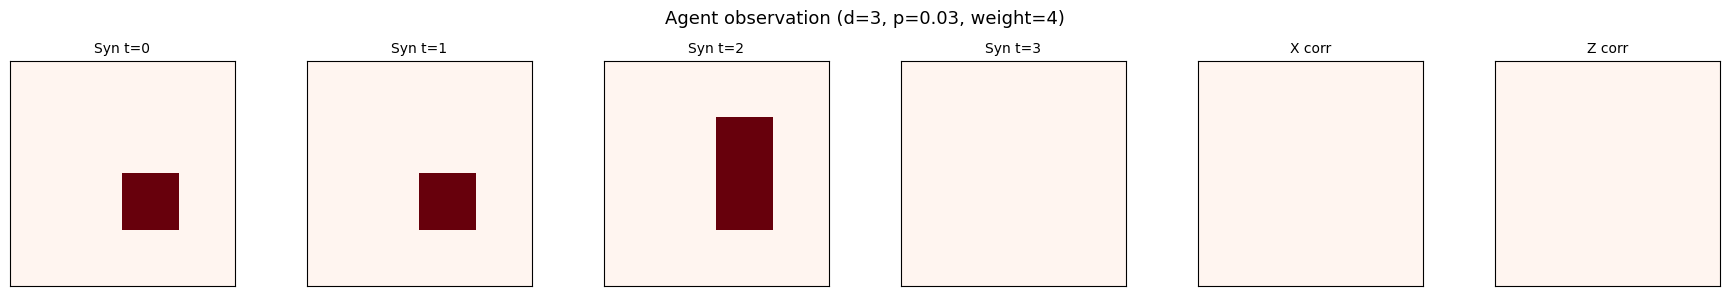

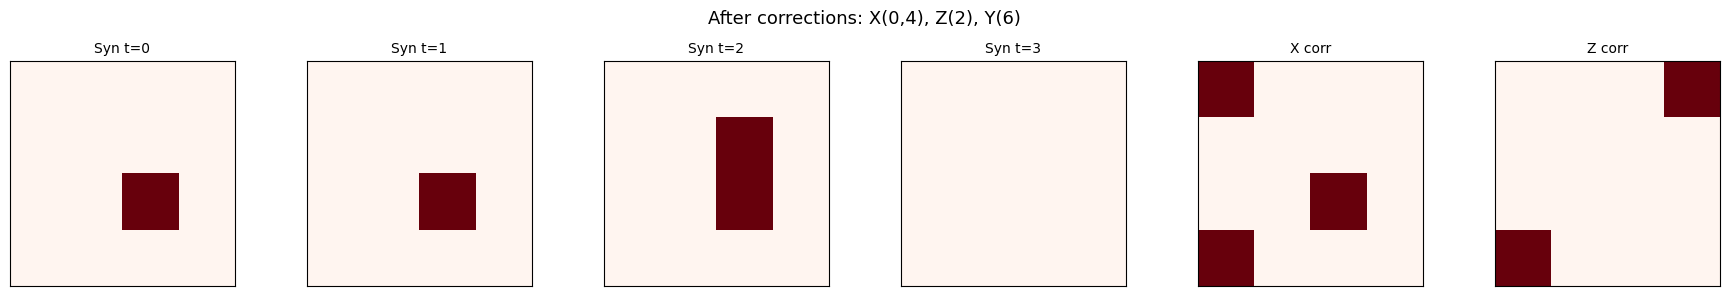

In [ ]:
env = SurfaceCodeEnv.from_config(distance=3, physical_error_rate=0.03)
obs, info = env.reset()

n_channels = obs.shape[0]
fig, axes = plt.subplots(1, n_channels, figsize=(3 * n_channels, 3))

channel_names = [f"Syn t={t}" for t in range(n_channels - 2)] + ["X corr", "Z corr"]

for i in range(n_channels):
    axes[i].imshow(obs[i], cmap='Reds', vmin=0, vmax=1, interpolation='nearest')
    axes[i].set_title(channel_names[i], fontsize=10)
    axes[i].set_xticks([])
    axes[i].set_yticks([])

fig.suptitle(f"Agent observation (d=3, p=0.03, weight={info['syndrome_weight']})", fontsize=13)
plt.tight_layout()
plt.show()

# apply some corrections and show updated observation
env.step(0)    # X on qubit 0
env.step(4)    # X on qubit 4
env.step(9+2)  # Z on qubit 2
obs_after, _, _, _, _ = env.step(18+6)  # Y on qubit 6

fig, axes = plt.subplots(1, n_channels, figsize=(3 * n_channels, 3))
for i in range(n_channels):
    axes[i].imshow(obs_after[i], cmap='Reds', vmin=0, vmax=1, interpolation='nearest')
    axes[i].set_title(channel_names[i], fontsize=10)
    axes[i].set_xticks([])
    axes[i].set_yticks([])

fig.suptitle("After corrections: X(0,4), Z(2), Y(6)", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Reward Variants

Compare the three reward strategies across episodes.

In [8]:
n_episodes = 500
reward_types = ["sparse", "potential_based", "heuristic_shaped"]

results = {}
for rtype in reward_types:
    env = SurfaceCodeEnv.from_config(
        distance=3, physical_error_rate=0.02, reward_type=rtype
    )
    episode_rewards = []
    episode_successes = []
    
    for _ in range(n_episodes):
        obs, _ = env.reset()
        total_reward = 0.0
        done = False
        while not done:
            # Random agent: mix of corrections and commits
            action = env.action_space.sample()
            obs, reward, term, trunc, info = env.step(action)
            total_reward += reward
            done = term or trunc
        episode_rewards.append(total_reward)
        episode_successes.append(info.get('success', False))
    
    results[rtype] = {
        'rewards': episode_rewards,
        'success_rate': np.mean(episode_successes),
        'mean_reward': np.mean(episode_rewards),
        'std_reward': np.std(episode_rewards),
    }
    print(f"{rtype:20s}: success_rate={results[rtype]['success_rate']:.3f}, "
          f"mean_reward={results[rtype]['mean_reward']:.3f} ± {results[rtype]['std_reward']:.3f}")

sparse              : success_rate=0.526, mean_reward=0.052 ± 0.999
potential_based     : success_rate=0.546, mean_reward=5.038 ± 2.740
heuristic_shaped    : success_rate=0.510, mean_reward=-0.035 ± 0.999


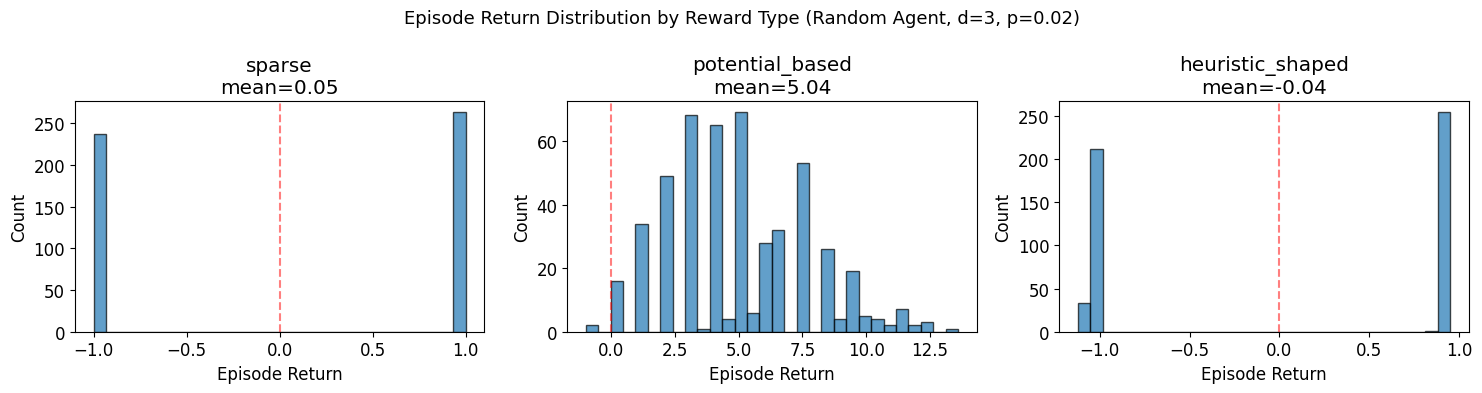

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, rtype in enumerate(reward_types):
    axes[i].hist(results[rtype]['rewards'], bins=30, alpha=0.7, edgecolor='black')
    axes[i].set_title(f"{rtype}\nmean={results[rtype]['mean_reward']:.2f}")
    axes[i].set_xlabel('Episode Return')
    axes[i].set_ylabel('Count')
    axes[i].axvline(0, color='red', linestyle='--', alpha=0.5)

fig.suptitle('Episode Return Distribution by Reward Type (Random Agent, d=3, p=0.02)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Oracle Verification

Critical week 2 checkpoint: verify the environment's reward computation is correct.

### 5a. Zero noise: commit-only agent should always succeed

In [10]:
env = SurfaceCodeEnv.from_config(distance=3, physical_error_rate=0.0)
successes = 0
n_test = 500

for _ in range(n_test):
    env.reset()
    done = False
    while not done:
        _, _, term, trunc, info = env.step(env._commit_action)
        done = term or trunc
    if info.get('success'):
        successes += 1

print(f"Zero noise, commit-only: {successes}/{n_test} = {successes/n_test:.1%} success rate")
assert successes == n_test, "Should be 100% at zero noise!"
print("✓ PASSED: Perfect success at zero noise")

Zero noise, commit-only: 500/500 = 100.0% success rate
✓ PASSED: Perfect success at zero noise


### 5b. Nonzero noise: MWPM should outperform commit-only

In [ ]:
distances = [3, 5]
p = 0.01
n_eval = 5000

comparison = []

for d in distances:
    params = SurfaceCodeParams(distance=d, rounds=d)
    config = NoiseConfig(NoiseModelType.DEPOLARIZING, p)
    circuit = build_noisy_circuit(params, config)
    
    # MWPM baseline
    decoder = MWPMDecoder.from_surface_code_circuit(circuit)
    syndromes, observables = circuit.sample(n_eval, seed=42)
    mwpm_result = decoder.evaluate(syndromes, observables)
    
    # commit-only agent
    env = SurfaceCodeEnv(circuit=circuit, reward_type="sparse")
    commit_successes = 0
    for _ in range(n_eval):
        env.reset()
        done = False
        while not done:
            _, _, term, trunc, info = env.step(env._commit_action)
            done = term or trunc
        if info.get('success'):
            commit_successes += 1
    
    commit_ler = 1.0 - commit_successes / n_eval
    mwpm_ler = mwpm_result['logical_error_rate']
    
    comparison.append({
        'distance': d,
        'mwpm_ler': mwpm_ler,
        'commit_only_ler': commit_ler,
        'mwpm_better': mwpm_ler < commit_ler,
    })

df_cmp = pd.DataFrame(comparison)
print(df_cmp.to_string(index=False))
print()
for _, row in df_cmp.iterrows():
    status = '✓' if row['mwpm_better'] else '✗'
    print(f"{status} d={row['distance']}: MWPM LER={row['mwpm_ler']:.4f} vs "
          f"commit-only LER={row['commit_only_ler']:.4f}")

 distance  mwpm_ler  commit_only_ler  mwpm_better
        3    0.0584           0.1888         True
        5    0.0850           0.3498         True

✓ d=3: MWPM LER=0.0584 vs commit-only LER=0.1888
✓ d=5: MWPM LER=0.0850 vs commit-only LER=0.3498


## 6. Random Agent Episode Statistics

Characterize the environment with a random agent to understand baseline behavior.

In [12]:
n_episodes = 1000
env = SurfaceCodeEnv.from_config(distance=3, physical_error_rate=0.01)

episode_lengths = []
episode_returns = []
episode_successes = []
correction_counts = []

for _ in range(n_episodes):
    obs, _ = env.reset()
    done = False
    steps = 0
    total_reward = 0.0
    n_corrections = 0
    
    while not done:
        action = env.action_space.sample()
        obs, reward, term, trunc, info = env.step(action)
        total_reward += reward
        if action != env._commit_action:
            n_corrections += 1
        steps += 1
        done = term or trunc
    
    episode_lengths.append(steps)
    episode_returns.append(total_reward)
    episode_successes.append(info.get('success', False))
    correction_counts.append(n_corrections)

print(f"Random agent stats (d=3, p=0.01, {n_episodes} episodes):")
print(f"  Episode length: {np.mean(episode_lengths):.1f} ± {np.std(episode_lengths):.1f}")
print(f"  Corrections/episode: {np.mean(correction_counts):.1f} ± {np.std(correction_counts):.1f}")
print(f"  Success rate: {np.mean(episode_successes):.3f}")
print(f"  Mean return: {np.mean(episode_returns):.3f} ± {np.std(episode_returns):.3f}")

Random agent stats (d=3, p=0.01, 1000 episodes):
  Episode length: 6.7 ± 1.8
  Corrections/episode: 6.5 ± 1.4
  Success rate: 0.524
  Mean return: 0.048 ± 0.999


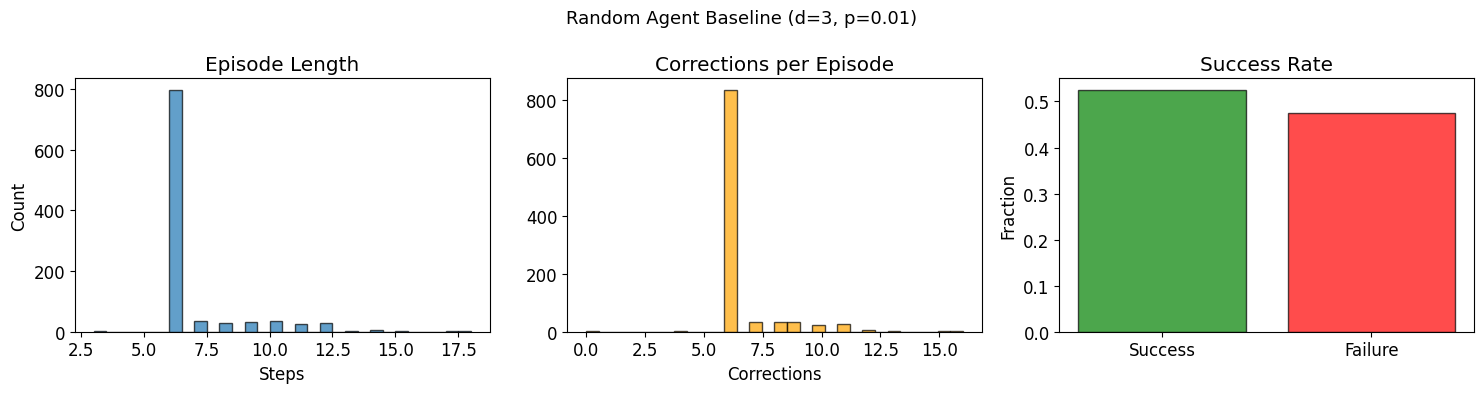

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(episode_lengths, bins=30, alpha=0.7, edgecolor='black')
axes[0].set_title('Episode Length')
axes[0].set_xlabel('Steps')
axes[0].set_ylabel('Count')

axes[1].hist(correction_counts, bins=30, alpha=0.7, edgecolor='black', color='orange')
axes[1].set_title('Corrections per Episode')
axes[1].set_xlabel('Corrections')

axes[2].bar(['Success', 'Failure'],
            [np.mean(episode_successes), 1 - np.mean(episode_successes)],
            color=['green', 'red'], alpha=0.7, edgecolor='black')
axes[2].set_title('Success Rate')
axes[2].set_ylabel('Fraction')

fig.suptitle('Random Agent Baseline (d=3, p=0.01)', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Environment Scaling with Distance

Check that the environment works for d=3, 5, and 7, and characterize the scaling.

In [ ]:
scaling_data = []

for d in [3, 5, 7]:
    env = SurfaceCodeEnv.from_config(distance=d, physical_error_rate=0.01)
    obs, info = env.reset()
    
    row = {
        'distance': d,
        'obs_shape': str(obs.shape),
        'n_channels': obs.shape[0],
        'grid_h': obs.shape[1],
        'grid_w': obs.shape[2],
        'obs_size': np.prod(obs.shape),
        'n_actions': env.action_space.n,
        'data_qubits': d**2,
    }
    scaling_data.append(row)
    
    done = False
    while not done:
        _, _, term, trunc, _ = env.step(env._commit_action)
        done = term or trunc

df_scale = pd.DataFrame(scaling_data)
print(df_scale.to_string(index=False))
print("\n✓ All distances run successfully")

 distance  obs_shape  n_channels  grid_h  grid_w  obs_size  n_actions  data_qubits
        3  (6, 4, 4)           6       4       4        96         28            9
        5  (8, 6, 6)           8       6       6       288         76           25
        7 (10, 8, 8)          10       8       8       640        148           49

✓ All distances run successfully


## 8. Noise Model Comparison in Environment

Compare commit-only success rates under depolarizing vs measurement-dominated noise.

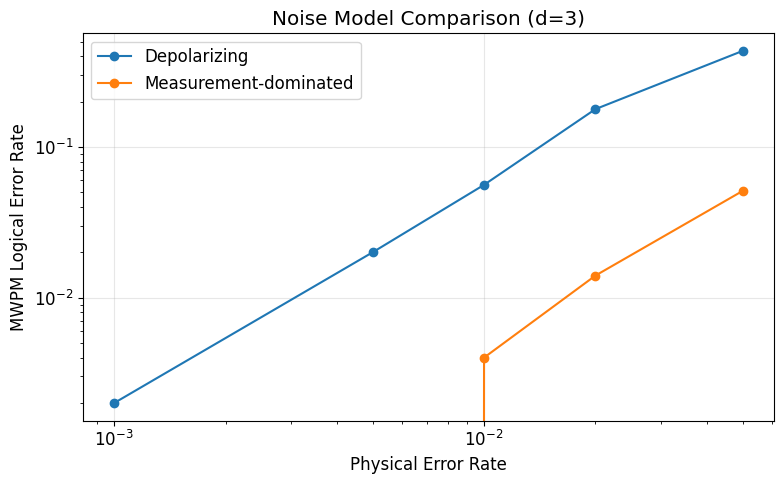

In [15]:
error_rates = [0.001, 0.005, 0.01, 0.02, 0.05]
noise_types = {
    'Depolarizing': NoiseModelType.DEPOLARIZING,
    'Measurement-dominated': NoiseModelType.MEASUREMENT,
}
n_eval = 1000
d = 3

noise_results = {name: [] for name in noise_types}

for name, ntype in noise_types.items():
    for p in error_rates:
        params = SurfaceCodeParams(distance=d, rounds=d)
        config = NoiseConfig(ntype, p)
        circuit = build_noisy_circuit(params, config)
        
        # MWPM LER
        decoder = MWPMDecoder.from_surface_code_circuit(circuit)
        syn, obs = circuit.sample(n_eval, seed=42)
        mwpm_res = decoder.evaluate(syn, obs)
        
        noise_results[name].append({
            'p': p,
            'mwpm_ler': mwpm_res['logical_error_rate'],
        })

fig, ax = plt.subplots(figsize=(8, 5))
for name, data in noise_results.items():
    ps = [r['p'] for r in data]
    lers = [r['mwpm_ler'] for r in data]
    ax.plot(ps, lers, 'o-', label=name, markersize=6)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Physical Error Rate')
ax.set_ylabel('MWPM Logical Error Rate')
ax.set_title(f'Noise Model Comparison (d={d})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()